<a href="https://colab.research.google.com/github/ds-20195/notebooks/blob/main/supplemental_materials/notebook3_cleaning_geometry_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cleaning Geometry Data -- supplemental

This is a supplemental notebook meant to accompany Notebook3. Within this notebook, we
will outline the full process necessary to produce the following files used in lab:

- `notebook3_census_2010_p3_filtered_block_df.parquet`
- `notebook3_ma_2010_filtered_block_gdf.parquet`


> Note: Parquet is a type of file commonly used to store columnar data (e.g. spreadsheets and dataframes). It generally compresses well (compression is applied automatically in Pandas), so it is great for storing large tables.

In [ ]:
%config InlineBackend.figure_formats = ["retina"]

import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd
import maup

from census import Census

state_fips  = "17"    # Illinois
county_fips = "031"   # Cook County
state_name  = "Illinois"
county_name = "Cook County"

census_ma = Census("", year=2010)

## Preparing the geometries

The main goal of the second half of lab 3 was to determine voter turnout across Massachusetts.
To do this, we will need to determine the number of voters in each voting precinct and estimate
the fraction of the citizen voting age population that showed up to vote in a given election.

We begin by obtaining a precinct shapefile published by the state
(see [https://www.mass.gov/info-details/massgis-data-2012-wards-and-precincts](https://www.mass.gov/info-details/massgis-data-2012-wards-and-precincts))
and the block shapefile published by the census.

In [ ]:
ma_ward_precinct_gdf = gpd.read_file("https://s3.us-east-1.amazonaws.com/download.massgis.digital.mass.gov/shapefiles/state/wardsprecincts_poly.zip")

#  A little bit of cleaning to make an index column that will work with the election data in Notebook3
def to_title_case(s):
    return s.title()

ma_ward_precinct_gdf["TOWN"] = ma_ward_precinct_gdf["TOWN"].apply(to_title_case)
ma_ward_precinct_gdf = ma_ward_precinct_gdf[["TOWN", "WARD", "PRECINCT", "DISTRICT", "geometry"]]
ma_ward_precinct_gdf.rename(columns={"DISTRICT": "VTD"}, inplace=True)
ma_ward_precinct_gdf["Name"] = (
    ma_ward_precinct_gdf["TOWN"] +
    " Ward " + ma_ward_precinct_gdf["WARD"].astype(str) +
    " Precinct " + ma_ward_precinct_gdf["PRECINCT"].astype(str)
)
ma_ward_precinct_gdf.set_index("Name", inplace=True)

In [ ]:
# Load the 2010 census blocks for Massachusetts (this will take some time to finish)
ma_2010_census_blocks_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2010/TABBLOCK/2010/tl_2010_25_tabblock10.zip")

ma_2010_census_blocks_gdf.set_index("GEOID10", inplace=True)

Before we proceed, we need to make sure the block data and the ward precinct data
are in the same CRS (see the top of Notebook3 for more details).

In [ ]:
ma_2010_census_blocks_gdf = ma_2010_census_blocks_gdf.to_crs(ma_ward_precinct_gdf.crs)

Recall that census blocks are the finest unit of geometry that are published by the census, and,
_theoretically_ any other piece of political geometry should be comprised of these block units. So,
if we wish to determine the population of a precinct, we only need to determine which census blocks
lie within that precinct and then aggregate the values.

In general, this sort of geometry operation can be tricky, but the MAUP package has a function called
`assign` which handles a significant portion of the work.

In [ ]:
block_to_precinct_assignment_ma = maup.assign(
    ma_2010_census_blocks_gdf, ma_ward_precinct_gdf
)

block_to_precinct_assignment_ma

/mnt/efs/h/Dropbox/MADLAB/Moon_Class_Work/ds-20195/notebooks/.venv/lib/python3.13/site-packages/maup/assign.py:32: AssigmentWarning: Warning: Some units in the source geometry were unassigned.
  warnings.warn(


GEOID10
250010153001070     Barnstable Ward None Precinct 1
250010125022055    Barnstable Ward None Precinct 13
250010127002018     Barnstable Ward None Precinct 4
250010125022026    Barnstable Ward None Precinct 13
250010122003103    Barnstable Ward None Precinct 11
                                 ...               
250277441022027        Milford Ward None Precinct 5
250277441021016        Milford Ward None Precinct 6
250277444002012        Milford Ward None Precinct 6
250277444002002        Milford Ward None Precinct 6
250277441013009        Milford Ward None Precinct 8
Length: 157508, dtype: object

In the output of the above cell, we see the index of the block dataframe on the left and the
index of the precinct dataframe on the right. This can be read as a dictionary saying
"block X is assigned to precinct Y"

The above cell should've also generated a warning indicating that some of the blocks were not
assignable to precincts. In other words, there were some blocks which did not have any of their
area contained within one of the precinct polygons. Such blocks map to a sentinal `nan` (not a number)
value, and we will need to determine what is going on with these blocks before proceeding.

First, how many are there?

In [ ]:
block_to_precinct_assignment_ma.isna().sum()

np.int64(603)

A rather significant number, and it would be helpful to visualize them. So, we will join
our block -> precinct assignment to the block dataframe and use filters to color the unassigned regions.

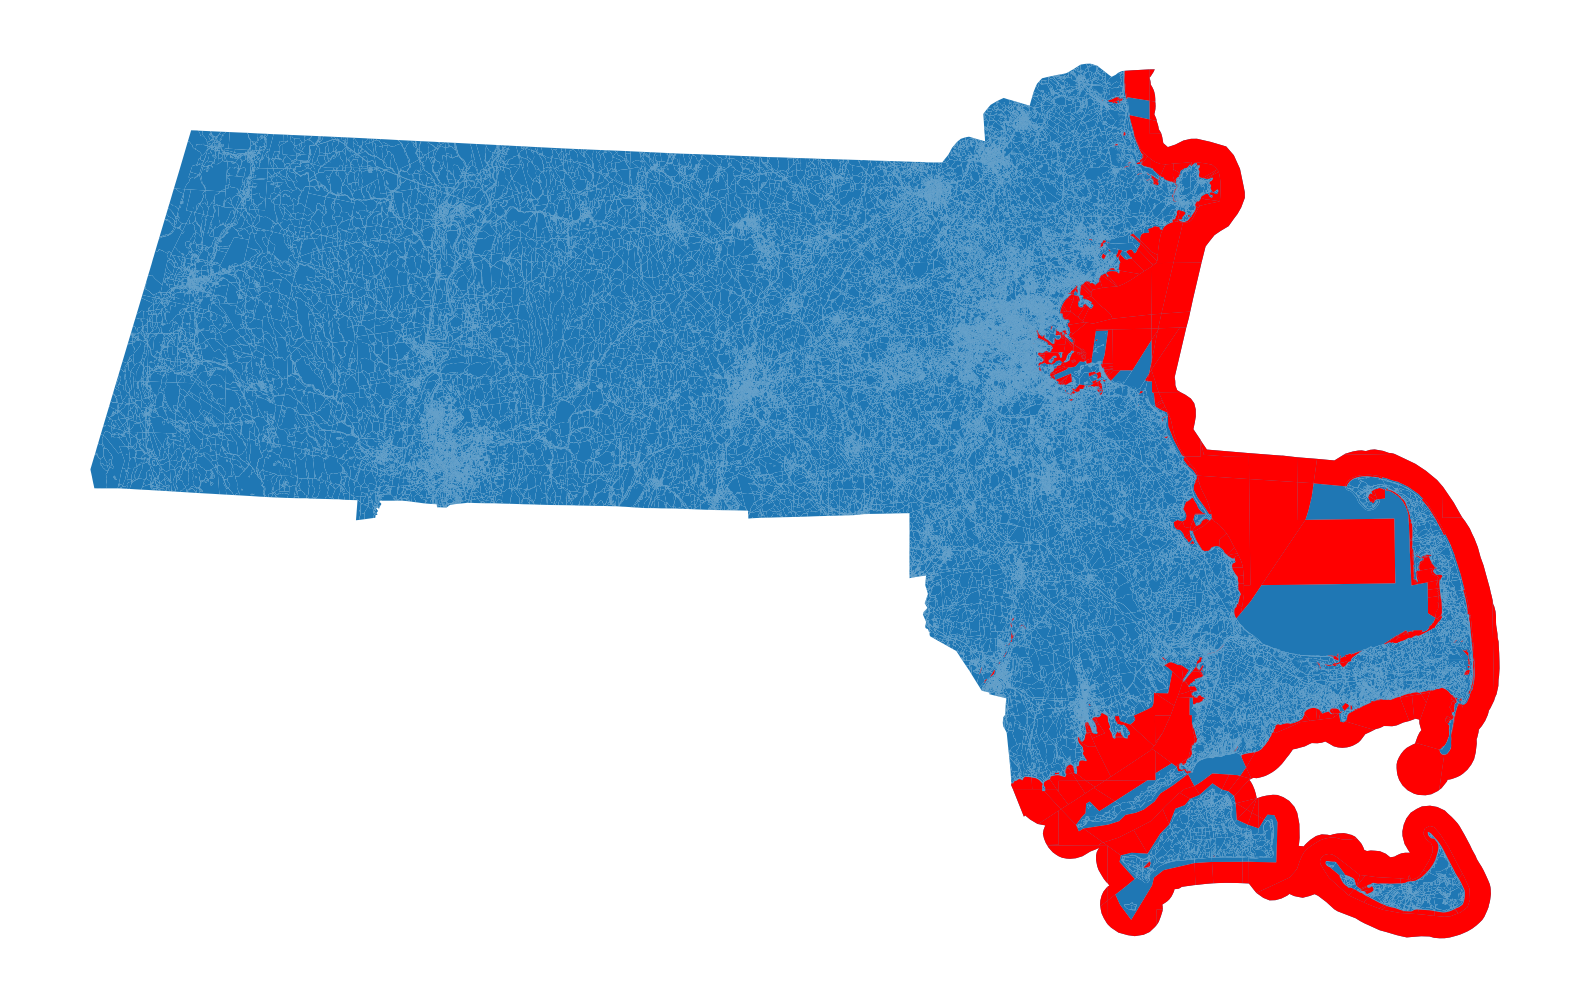

In [ ]:
# Add the assignment column
ma_2010_census_blocks_gdf["assignment"] = block_to_precinct_assignment_ma

fig, ax = plt.subplots(figsize=(10, 10))

# Plot all of the blocks with the default blue color
ax = ma_2010_census_blocks_gdf.plot(ax=ax)

unassigned_blocks_mask = ma_2010_census_blocks_gdf["assignment"].isna()
unassigned_blocks_gdf = ma_2010_census_blocks_gdf[unassigned_blocks_mask]

# Plot the unassigned blocks with a red color and some transparency so we can see the blue blocks underneath
ax = unassigned_blocks_gdf.plot(ax=ax, color="red")

ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False); ax.spines['bottom'].set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
plt.show()

It appears that all of the unassigned regions are water. We will check to make sure that no
people live there, and, if so, these unassigned regions can be safely ignored. Before we can
do that, however, we will need population data.

We have downloaded the block-level P3 table for MA from the Census already, so we load it below.
Table P3 contains only those persons who are above the age of 18, so a population of zero
here indicates a block that is unlikely to have any voters in it.

In [ ]:
census_2010_p3_block_df = pd.read_csv("https://github.com/ds-20195/notebooks/raw/refs/heads/main/supplemental_materials/data/25_block_2010_P3.zip").set_index("id")
census_2010_p3_block_df.index = census_2010_p3_block_df.index.astype(str)
census_2010_p3_block_df = census_2010_p3_block_df[["p003001"]]
census_2010_p3_block_df["p003001"] = census_2010_p3_block_df["p003001"].astype(int)

census_2010_p3_block_df = census_2010_p3_block_df.rename(columns={"p003001": "VAP"})

# We rename the index to something more descriptive here.
census_2010_p3_block_df = census_2010_p3_block_df.rename_axis("GEOID10")
census_2010_p3_block_df["VAP"].sum()

np.int64(5128706)

Now, we validate that the unassigned blocks contain no voters.

In [ ]:
census_2010_p3_block_df["assignment"] = block_to_precinct_assignment_ma.astype(str)
p3_unassigned_blocks_mask = census_2010_p3_block_df["assignment"].isna()


census_2010_p3_block_df[p3_unassigned_blocks_mask]["VAP"].sum()

np.int64(0)

The population of those unassigned blocks does appear to be zero, so we can drop them from the dataframe.

In [ ]:
# "~" is the "not" operator which flips the boolean values in the mask.
ma_2010_filtered_block_gdf = ma_2010_census_blocks_gdf.loc[~unassigned_blocks_mask ]
ma_2010_census_blocks_gdf

,STATEFP10,COUNTYFP10,TRACTCE10,BLOCKCE10,NAME10,MTFCC10,UR10,UACE10,UATYP10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry,assignment
GEOID10,,,,,,,,,,,,,,,,
250010153001070,25,001,015300,1070,Block 1070,G5040,U,05167,U,S,3079,0,+41.6823046,-070.2946882,"POLYGON ((300343.481 826455.61, 300311.478 826...",Barnstable Ward None Precinct 1
250010125022055,25,001,012502,2055,Block 2055,G5040,U,05167,U,S,1339,0,+41.6422728,-070.2879171,"POLYGON ((300973.964 822022.725, 300968.868 82...",Barnstable Ward None Precinct 13
250010127002018,25,001,012700,2018,Block 2018,G5040,U,05167,U,S,8752,0,+41.6553900,-070.3486261,"POLYGON ((295833.171 823380.659, 295851.829 82...",Barnstable Ward None Precinct 4
250010125022026,25,001,012502,2026,Block 2026,G5040,U,05167,U,S,3286,0,+41.6434607,-070.2886836,"POLYGON ((300836.873 822165.403, 300832.174 82...",Barnstable Ward None Precinct 13
250010122003103,25,001,012200,3103,Block 3103,G5040,R,None,None,S,566039,0,+41.7049820,-070.3466595,"POLYGON ((296462.724 828486.656, 296475.267 82...",Barnstable Ward None Precinct 11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250277441022027,25,027,744102,2027,Block 2027,G5040,U,09271,U,S,53284,0,+42.1471467,-071.5392222,"POLYGON ((196880.882 877262.024, 196906.562 87...",Milford Ward None Precinct 5
250277441021016,25,027,744102,1016,Block 1016,G5040,U,09271,U,S,44813,0,+42.1518429,-071.5393596,"POLYGON ((196919.335 878056.951, 196922.722 87...",Milford Ward None Precinct 6
250277444002012,25,027,744400,2012,Block 2012,G5040,U,09271,U,S,29847,0,+42.1486500,-071.5388099,"POLYGON ((196798.678 877716.902, 196850.624 87...",Milford Ward None Precinct 6


In [ ]:
# This is how we saved the data
# ma_2010_filtered_block_gdf.to_parquet("notebook3_ma_2010_filtered_block_gdf.parquet", compression="zstd")

And we can now save the necessary P3 populations as well.

In [ ]:
census_2010_p3_filtered_block_df = census_2010_p3_block_df.loc[~p3_unassigned_blocks_mask]
census_2010_p3_filtered_block_df["tract_geo_id"] = census_2010_p3_filtered_block_df.index.str[:11]

# census_2010_p3_filtered_block_df.to_parquet("notebook3_census_2010_p3_filtered_block_df.parquet")